In [1]:
import os
from tqdm.notebook import tqdm
from IPython.display import HTML

import torch
import numpy as np
import plotly.express as px
from torch import nn, Tensor
import matplotlib.colors as mcolors
from matplotlib import pyplot as plt
from torchvision.transforms import v2
from matplotlib.animation import FuncAnimation

from src import configs as cfg
from src import dataset, models

/root/repos/raidium_challenge/.venv/lib/python3.13/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [2]:
def load_chkpt(chkpt_pth: str) -> torch.nn.Module:
    chkpt = torch.load(chkpt_pth, weights_only=False)
    model_cfg = cfg.ModelConfig(**chkpt["model_cfg"])
    model = models.mk_model_from_cfg(model_cfg)
    model.load_state_dict(chkpt["model"])
    model = model.eval()
    return model

In [3]:
train_cfg = cfg.TrainingConfig(batch_size=5)
loaders = dataset.mk_segmentation_data_loaders(train_cfg)
x, y_true = next(iter(loaders["train"]))
batch = dataset.preprocess_batch({"x": x, "y_true": y_true})

CHKPT_DIRECTORY = "checkpoints/unet/devout-fog-532/"

N_CHKPT_TO_PLT = -1
chkpt_filenames = os.listdir(CHKPT_DIRECTORY)[:N_CHKPT_TO_PLT]
segs_buffer = torch.empty(
    len(chkpt_filenames), train_cfg.batch_size, 256, 256,
    dtype=torch.uint8,
    device=cfg.DEVICE,
)

with torch.no_grad():
    for chkpt_idx, chkpt_filename in enumerate(tqdm(chkpt_filenames)):
        chkpt_pth = os.path.join(CHKPT_DIRECTORY, chkpt_filename)
        model = load_chkpt(chkpt_pth)
        with torch.autocast(cfg.DEVICE.type, torch.bfloat16):
            segs_buffer[chkpt_idx] = (
                model(batch)["y_pred"]
                .argmax(dim=1)
                .to(dtype=torch.uint8)
            )

sampling method: shuffle
train_dl_kwargs: {'shuffle': True, 'batch_size': 5}


  0%|          | 0/599 [00:00<?, ?it/s]

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import plotly.express as px

N_SAMPLES_TO_SHOW = 10


# For segmentation labels (categorical)
seg_norm = Normalize(
    vmin=0,
    vmax=cfg.N_CLASSES - 1,   # important: categorical, fixed range
)

segs_buffer_np = segs_buffer.cpu().numpy()  # [B, H, W]

colored_seg_buffer = plt.cm.rainbow(
    seg_norm(segs_buffer_np)
)  # -> [B, H, W, 4]

# For grayscale images
# Adjust depending on your preprocessing
x_np = batch["x"].cpu().numpy()  # [B, H, W, C] or [B, H, W]


In [5]:
x_norm = Normalize(
    vmin=x_np.min(),
    vmax=x_np.max(),
)

colored_x = plt.cm.gray(x_norm(x_np))  # -> [B, H, W, 4]

seg_mask = (segs_buffer_np == 0)[..., None]  # background mask

test_img_buffer = np.where(
    seg_mask,
    colored_x[None, :, 0],
    colored_seg_buffer,
)

# Remove alpha channel
test_img_buffer = test_img_buffer[..., :3]  # [model_step, B, H, W, 3]

TypeError: Invalid shape (1, 256, 3, 4) for image data

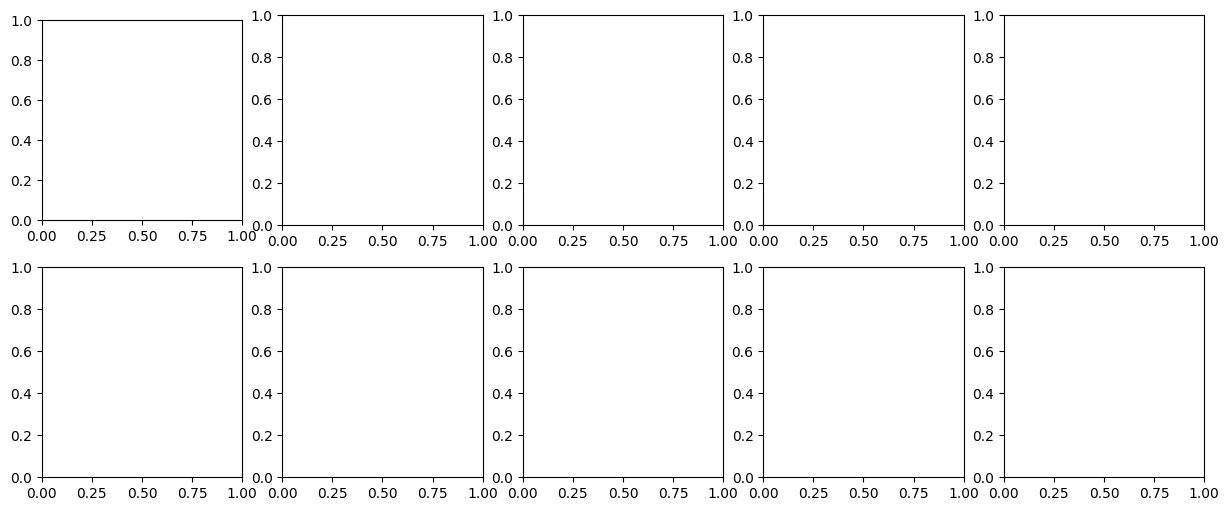

In [6]:
T, B, H, W, _ = test_img_buffer.shape

# Normalize inputs for display
x_norm = Normalize(vmin=x_np.min(), vmax=x_np.max())
x_gray = plt.cm.gray(x_norm(x_np))[:, :, :, :3]  # [B, H, W, 3]

fig, axes = plt.subplots(
    2, B,
    figsize=(3 * B, 6),
    squeeze=False
)

# --- First row: input images (static) ---
for j in range(B):
    axes[0, j].imshow(x_gray[j])
    axes[0, j].set_title(f"Input {j}")
    axes[0, j].axis("off")

# --- Second row: segmentation predictions (animated) ---
seg_ims = []
for j in range(B):
    im = axes[1, j].imshow(test_img_buffer[0, j])
    axes[1, j].set_title(f"Pred {j}")
    axes[1, j].axis("off")
    seg_ims.append(im)

def update(t):
    for j in range(B):
        seg_ims[j].set_data(test_img_buffer[t, j])
    return seg_ims

anim = FuncAnimation(
    fig,
    update,
    frames=T,
    interval=30,
    blit=False,
    repeat=True,
)

plt.tight_layout()

In [ ]:
anim.save(
    "segmentation_animation.mp4",
    fps=30,
    dpi=150,
)